# ANN-UTADIS for preference learning

In [8]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

cwd = Path.cwd()
project_root = cwd if (cwd / "data").exists() else cwd.parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.ann_utadis import (
    AnnUtadis,
    PreferenceMinMaxScaler,
    create_dataloaders,
    predict_ann_utadis,
    save_ann_utadis_bundle,
    train_ann_utadis,
)
from src.metrics import evaluate_model

## Load hospital data and binarize target
Binary target:
- 1 = good hospital (`hospital_overall_rating >= 4`)
- 0 = bad hospital

In [9]:
data_path = project_root / "data" / "hospital_data.csv"
df = pd.read_csv(data_path)

cost_cols = [
    "mort_ami",
    "comp_hip_knee",
    "readmission_hf",
    "spending",
    "count_of_readm_measures_worse",
]
gain_cols = ["count_of_safety_measures_better"]
feature_cols = cost_cols + gain_cols

model_df = df.copy()

model_df["target"] = (model_df["hospital_overall_rating"] >= 4).astype(int)

X = model_df[feature_cols]
y = model_df["target"]

print("Rows:", len(model_df))
print("Class balance:")
print(y.value_counts(normalize=True).rename("share").round(4))

Rows: 500
Class balance:
target
0    0.602
1    0.398
Name: share, dtype: float64


## Split train/test and normalize criteria to [0, 1]
For normalization, 1 means the most preferred value and 0 the least preferred.

In [10]:
X_train_df, X_test_df, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = PreferenceMinMaxScaler(gain_columns=gain_cols, cost_columns=cost_cols)
X_train_norm = scaler.fit_transform(X_train_df)
X_test_norm = scaler.transform(X_test_df)

# Sanity check: all criteria are in [0, 1]
print("Train min:", float(X_train_norm.min().min()), "Train max:", float(X_train_norm.max().max()))
print("Test min:", float(X_test_norm.min().min()), "Test max:", float(X_test_norm.max().max()))
print("Train shape:", X_train_norm.shape, "Test shape:", X_test_norm.shape)

Train min: 0.0 Train max: 1.0
Test min: 0.0 Test max: 1.0
Train shape: (400, 6) Test shape: (100, 6)


## Initialize and train ANN-UTADIS

In [11]:
train_loader, test_loader = create_dataloaders(
    X_train_norm.values,
    y_train.values,
    X_test_norm.values,
    y_test.values,
    batch_size=None,
)

model = AnnUtadis(
    num_criteria=len(feature_cols),
    num_hidden_components=30,
    slope=0.01,
    threshold=0.5,
)

model, history = train_ann_utadis(
    model=model,
    train_loader=train_loader,
    val_loader=test_loader,
    lr=1e-3,
    epochs=300,
    slope_decrease=True,
    device="cpu",
)

## Predict and evaluate

In [12]:
y_pred_test, y_prob_test = predict_ann_utadis(model, X_test_norm.values)
metrics = evaluate_model(y_test.values, y_pred_test, y_prob_test)

print("ANN-UTADIS test metrics (4 decimals):")
for name, value in metrics.items():
    print(f"{name}: {value:.4f}")

ANN-UTADIS test metrics (4 decimals):
accuracy: 0.8200
f1: 0.7907
auc: 0.9083


## Training curves

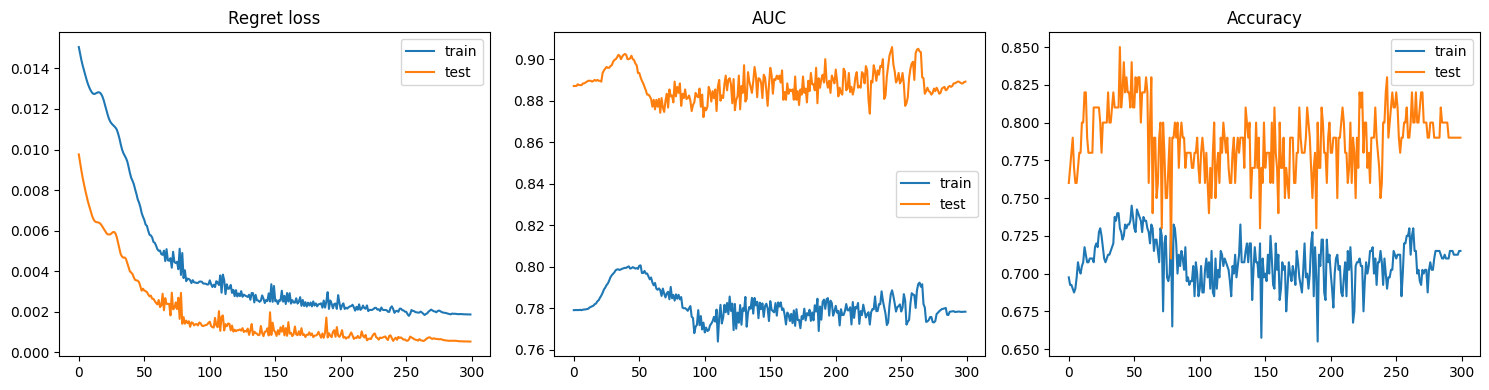

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history.train_loss, label="train")
axes[0].plot(history.val_loss, label="test")
axes[0].set_title("Regret loss")
axes[0].legend()

axes[1].plot(history.train_auc, label="train")
axes[1].plot(history.val_auc, label="test")
axes[1].set_title("AUC")
axes[1].legend()

axes[2].plot(history.train_acc, label="train")
axes[2].plot(history.val_acc, label="test")
axes[2].set_title("Accuracy")
axes[2].legend()

plt.tight_layout()

## Save model

In [14]:
models_dir = project_root / "models"
bundle_path = models_dir / "ann_utadis_hospital.pt"

metadata = {
    "feature_cols": feature_cols,
    "cost_cols": cost_cols,
    "gain_cols": gain_cols,
    "target_rule": "hospital_overall_rating >= 4 -> 1 else 0",
    "scaler_min": scaler.min_,
    "scaler_max": scaler.max_,
}
save_ann_utadis_bundle(model, bundle_path, metadata)
print(f"Saved ANN-UTADIS bundle to: {bundle_path}")

Saved ANN-UTADIS bundle to: /home/marek/put/DA/mcda/models/ann_utadis_hospital.pt
